# Product Review Intelligence System

## Aspect-Based Sentiment Analysis on Amazon Fine Food Reviews

This project builds an end-to-end NLP pipeline that:

1. Loads and explores customer reviews.
2. Cleans and preprocesses review text.
3. Converts star ratings into sentiment labels.
4. Trains a transformer sentiment classifier.
5. Extracts candidate product aspects using linguistic patterns.
6. Predicts sentiment for each aspect using the sentence containing that aspect.
7. Calculates prediction confidence.
8. Aggregates positive and negative aspects.
9. Builds interactive Plotly visualizations.
10. Provides a reusable `analyze_review()` function for new customer reviews.

**Dataset:** Amazon Fine Food Reviews — 568,454 reviews, 74,258 products, Oct 1999–Oct 2012.


## 1. Install dependencies

Kaggle already provides most scientific Python libraries. The following installs the NLP/model packages needed by this notebook.

In [21]:
!pip install -q -U transformers datasets accelerate evaluate spacy plotly
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 94.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.4/604.4 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 102.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 MB 34.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 39.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.48.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 69.1 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now

## 2. Imports and configuration

In [22]:
import os
import re
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import spacy
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

DATA_PATH = "/kaggle/input/datasets/maksudurrahmanaiml/amazon-fine-food-reviews/Reviews.csv"
MODEL_NAME = "distilbert-base-uncased"

# Keep the notebook practical on Kaggle.
MAX_TRAIN_PER_CLASS = 15000
MAX_TEST_PER_CLASS = 3000
MAX_LENGTH = 192


Device: cuda


## 3. Load the dataset

The Kaggle dataset contains `Summary`, `Text`, `Score`, product metadata, helpfulness information, and timestamps.

In [23]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
display(df[["Score", "Summary", "Text"]].head())

print("\nMissing values:")
display(df.isna().sum())

print("\nRating distribution:")
display(df["Score"].value_counts().sort_index())

Shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...



Missing values:


Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


Rating distribution:


Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

## 4. Basic data cleaning and EDA

In [24]:
df = df.drop_duplicates(subset=["UserId", "Time", "Text"]).copy()
df["Summary"] = df["Summary"].fillna("")
df["Text"] = df["Text"].fillna("")

df["review"] = (df["Summary"].str.strip() + ". " + df["Text"].str.strip()).str.strip()
df["review"] = df["review"].str.replace(r"\s+", " ", regex=True)

df["word_count"] = df["review"].str.split().str.len()
df["char_count"] = df["review"].str.len()

fig = px.histogram(
    df, x="Score", title="Star Rating Distribution",
    category_orders={"Score":[1,2,3,4,5]}
)
fig.show()

fig = px.histogram(
    df, x="word_count", nbins=80,
    title="Review Length Distribution"
)
fig.show()

display(df[["word_count", "char_count"]].describe())

,word_count,char_count
count,393892.000000,393892.000000
mean,83.921270,457.940458
std,78.035094,436.737273
min,4.000000,24.000000
25%,37.000000,202.000000
50%,61.000000,327.000000
75%,102.000000,553.000000
max,3451.000000,21442.000000


## 5. Create sentiment labels

The original dataset does not contain a manually annotated sentiment column. Therefore we use the rating as a **weak supervision signal**:

- 1–2 stars → Negative
- 4–5 stars → Positive
- 3 stars → excluded because it is ambiguous

This distinction should be mentioned in the project report as a limitation.

In [25]:
sentiment_df = df[df["Score"] != 3].copy()
sentiment_df["label"] = sentiment_df["Score"].apply(lambda x: 1 if x >= 4 else 0)
sentiment_df["sentiment"] = sentiment_df["label"].map({0: "negative", 1: "positive"})

print(sentiment_df["sentiment"].value_counts())
display(sentiment_df[["Score", "sentiment", "review"]].sample(5, random_state=SEED))

sentiment
positive    307021
negative     57103
Name: count, dtype: int64


,Score,sentiment,review
1824,5,positive,Good but didn't receive what was ordered. The ...
413495,5,positive,These are very effective in detecting moth pro...
196105,5,positive,Excellent Oatmeal. All of the Red Mill product...
503684,1,negative,"You get what you pay for, yuck.. These are are..."
61053,5,positive,Yummy!!. I'm drooling almost too much to write...


## 6. Balance and sample the training data

The full dataset is useful for EDA, but fine-tuning a transformer on all rows is unnecessarily expensive for a Kaggle project. We create a balanced subset for training and evaluation.

In [26]:
negative = sentiment_df[sentiment_df["label"] == 0]
positive = sentiment_df[sentiment_df["label"] == 1]

train_neg, test_neg = train_test_split(
    negative, test_size=MAX_TEST_PER_CLASS, random_state=SEED
)
train_pos, test_pos = train_test_split(
    positive, test_size=MAX_TEST_PER_CLASS, random_state=SEED
)

train_neg = train_neg.sample(
    n=min(MAX_TRAIN_PER_CLASS, len(train_neg)), random_state=SEED
)
train_pos = train_pos.sample(
    n=min(MAX_TRAIN_PER_CLASS, len(train_pos)), random_state=SEED
)

train_df = pd.concat([train_neg, train_pos]).sample(frac=1, random_state=SEED)
test_df = pd.concat([test_neg, test_pos]).sample(frac=1, random_state=SEED)

print("Train:", train_df.shape)
print("Test :", test_df.shape)
print(train_df["label"].value_counts())

Train: (30000, 15)
Test : (6000, 15)
label
0    15000
1    15000
Name: count, dtype: int64


## 7. Text preprocessing

For transformer models we deliberately keep preprocessing light. Removing stopwords and aggressively stemming words can destroy contextual information.

We only normalize obvious noise such as HTML, URLs, excessive whitespace, and repeated punctuation.

In [27]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"([!?.,])\1{2,}", r"\1", text)
    return text.strip()

train_df["clean_review"] = train_df["review"].map(clean_text)
test_df["clean_review"] = test_df["review"].map(clean_text)

display(train_df[["review", "clean_review"]].head())

,review,clean_review
503610,so sad about this one. We loved the Hodgson Mi...,so sad about this one. We loved the Hodgson Mi...
401124,Add more milk. You will need to add more milk ...,Add more milk. You will need to add more milk ...
250888,Garlic Gold is Golden. If you haven't tried it...,Garlic Gold is Golden. If you haven't tried it...
104891,Excruciatingly good.. It's sooooooooooooo good...,Excruciatingly good.. It's sooooooooooooo good...
553205,"Decent, not great.. I used to think this stuff...","Decent, not great.. I used to think this stuff..."


## 8. Tokenization

In [30]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 1. Convert Pandas DataFrames to Hugging Face Datasets
train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

# 2. Tokenization function (uses 'clean_review')
def tokenize(batch):
    return tokenizer(
        batch["clean_review"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

# 3. Apply tokenization
train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

# 4. Remove unneeded text columns and set format for PyTorch
train_ds = train_ds.remove_columns([col for col in ["review", "clean_review", "__index_level_0__"] if col in train_ds.column_names])
test_ds = test_ds.remove_columns([col for col in ["review", "clean_review", "__index_level_0__"] if col in test_ds.column_names])

train_ds.set_format("torch")
test_ds.set_format("torch")

print(train_ds)
print(test_ds)

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Dataset({
    features: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'word_count', 'char_count', 'label', 'sentiment', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 30000
})
Dataset({
    features: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'word_count', 'char_count', 'label', 'sentiment', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6000
})


In [31]:
print(train_ds)
print(test_ds)

Dataset({
    features: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'word_count', 'char_count', 'label', 'sentiment', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 30000
})
Dataset({
    features: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'word_count', 'char_count', 'label', 'sentiment', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6000
})


In [32]:
train_ds = train_ds.remove_columns(
    [col for col in ["__index_level_0__", "token_type_ids"] if col in train_ds.column_names]
)

test_ds = test_ds.remove_columns(
    [col for col in ["__index_level_0__", "token_type_ids"] if col in test_ds.column_names]
)

print(train_ds)
print(test_ds)

Dataset({
    features: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'word_count', 'char_count', 'label', 'sentiment', 'input_ids', 'attention_mask'],
    num_rows: 30000
})
Dataset({
    features: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'word_count', 'char_count', 'label', 'sentiment', 'input_ids', 'attention_mask'],
    num_rows: 6000
})


## 9. Fine-tune DistilBERT for sentiment classification

In [33]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0:"NEGATIVE", 1:"POSITIVE"},
    label2id={"NEGATIVE":0, "POSITIVE":1}
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

training_args = TrainingArguments(
    output_dir="/kaggle/working/product-review-model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=1
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.288969,0.223951,0.959500,0.967130,0.951333,0.959167
2,0.181545,0.259769,0.960000,0.961230,0.958667,0.959947


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1876, training_loss=0.2691790544147939, metrics={'train_runtime': 682.1264, 'train_samples_per_second': 87.96, 'train_steps_per_second': 2.75, 'total_flos': 2980516469760000.0, 'train_loss': 0.2691790544147939, 'epoch': 2.0})

## 10. Evaluate the sentiment model

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.181545,0.259769,2,0.960000,0.961230,0.958667,0.959947


{'eval_loss': 0.25976860523223877, 'eval_accuracy': 0.96, 'eval_precision': 0.9612299465240641, 'eval_recall': 0.9586666666666667, 'eval_f1': 0.9599465954606141}


              precision    recall  f1-score   support

    Negative     0.9588    0.9613    0.9601      3000
    Positive     0.9612    0.9587    0.9599      3000

    accuracy                         0.9600      6000
   macro avg     0.9600    0.9600    0.9600      6000
weighted avg     0.9600    0.9600    0.9600      6000



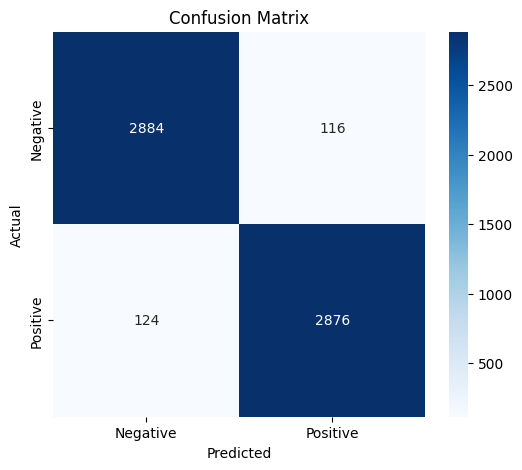

In [35]:
metrics = trainer.evaluate()
print(metrics)

pred_output = trainer.predict(test_ds)
pred_labels = np.argmax(pred_output.predictions, axis=-1)

print(classification_report(test_df["label"], pred_labels, target_names=["Negative", "Positive"], digits=4))

# Seaborn Confusion Matrix Plot
cm = confusion_matrix(test_df["label"], pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Negative", "Positive"], 
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 11. Candidate aspect extraction

An aspect is a product attribute or component discussed by the customer, such as:

- taste
- price
- packaging
- quality
- texture
- ingredients
- smell
- delivery

We use spaCy dependency parsing and noun chunks to generate candidate aspects. This is an **unsupervised candidate extraction** stage, so it does not require aspect labels.

In [36]:
import re
import spacy

nlp = spacy.load("en_core_web_sm")

GENERIC_TERMS = {
    # Generic nouns
    "thing", "stuff", "item", "product", "food", "review",
    "amazon", "purchase", "purchases", "time", "way",
    "lot", "bit", "one", "something", "someone", "people",

    # Pronouns
    "i", "me", "my", "mine", "myself",
    "you", "your", "yours", "yourself",
    "he", "him", "his", "himself",
    "she", "her", "hers", "herself",
    "it", "its", "itself",
    "we", "us", "our", "ours", "ourselves",
    "they", "them", "their", "theirs", "themselves",

    # Demonstratives
    "this", "that", "these", "those",

    # Interrogatives / relative pronouns
    "what", "which", "who", "whom", "whose",

    # Quantifiers
    "all", "some", "any", "many", "much",
    "few", "several", "each", "every",
    "everything", "nothing", "none"
}

def normalize_aspect(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s-]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

def extract_aspects(text, nlp_model=nlp):
    doc = nlp_model(text)
    aspects = set()

    # Noun chunks capture useful multi-word aspects.
    for chunk in doc.noun_chunks:
        phrase = normalize_aspect(chunk.text)
        if not phrase:
            continue
        words = phrase.split()
        if len(words) <= 4 and any(w.isalpha() for w in words):
            if not all(w in GENERIC_TERMS for w in words):
                aspects.add(phrase)

    # Nouns/proper nouns catch single-word aspects missed by chunks.
    for token in doc:
        if token.pos_ in {"NOUN", "PROPN"} and not token.is_stop:
            lemma = normalize_aspect(token.lemma_)
            if (
                len(lemma) >= 3
                and lemma.isalpha()
                and lemma not in GENERIC_TERMS
            ):
                aspects.add(lemma)

    return sorted(aspects)

example = "The taste is excellent but the packaging is cheap and the texture is too dry."
print(extract_aspects(example))

['packaging', 'taste', 'texture', 'the packaging', 'the taste', 'the texture']


## 12. Discover frequent candidate aspects

Running spaCy over all 568K reviews is expensive. We use a representative sample to discover the vocabulary of common aspects, then use those candidates in the intelligence pipeline.

In [37]:
ASPECT_SAMPLE_SIZE = min(30000, len(sentiment_df))
aspect_sample = sentiment_df.sample(ASPECT_SAMPLE_SIZE, random_state=SEED)

aspect_counter = Counter()

for doc in nlp.pipe(
    aspect_sample["review"].tolist(),
    batch_size=64
):
    for chunk in doc.noun_chunks:
        phrase = normalize_aspect(chunk.text)
        if 1 <= len(phrase.split()) <= 4:
            words = phrase.split()
            if any(w.isalpha() for w in words) and not all(w in GENERIC_TERMS for w in words):
                aspect_counter[phrase] += 1

top_aspects = pd.DataFrame(
    aspect_counter.most_common(30),
    columns=["aspect", "frequency"]
)

display(top_aspects.head(20))

fig = px.bar(
    top_aspects.head(20).sort_values("frequency"),
    x="frequency", y="aspect", orientation="h",
    title="Top Candidate Aspects"
)
fig.show()

,aspect,frequency
0,the taste,1618
1,the price,1573
2,coffee,1421
3,the flavor,1309
4,a lot,1284
5,this tea,1248
6,the product,1191
7,anything,1071
8,sugar,1041
9,water,940


## 13. Aspect-level sentiment engine

The trained classifier predicts sentiment for a piece of text. To obtain aspect-level sentiment:

1. Split a review into sentences.
2. Extract candidate aspects from each sentence.
3. Find the sentence containing the aspect.
4. Send that sentence to the trained sentiment model.
5. Store the predicted label and softmax probability as confidence.

This gives an interpretable aspect → sentiment → confidence record.

In [40]:
import torch.nn.functional as F

id2label = {0: "negative", 1: "positive"}

def predict_sentiment(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits
        probabilities = F.softmax(logits, dim=-1)[0]

    label_id = int(torch.argmax(probabilities).item())
    confidence = float(probabilities[label_id].item())

    return id2label[label_id], confidence

def aspect_sentiment(review, min_confidence=0.55):
    doc = nlp(review)
    results = []

    for sent in doc.sents:
        sentence = sent.text.strip()
        if not sentence:
            continue

        aspects = extract_aspects(sentence)

        if not aspects:
            continue

        sentiment, confidence = predict_sentiment(sentence)

        if confidence >= min_confidence:
            for aspect in aspects:
                results.append({
                    "aspect": aspect,
                    "sentiment": sentiment,
                    "confidence": round(confidence, 4),
                    "sentence": sentence
                })

    return pd.DataFrame(results)

demo_review = (
    "The taste is excellent and the ingredients seem fresh. "
    "However, the packaging is cheap and the texture is too dry."
)

demo_result = aspect_sentiment(demo_review)
display(demo_result)

,aspect,sentiment,confidence,sentence
0,ingredient,positive,0.9987,The taste is excellent and the ingredients see...
1,taste,positive,0.9987,The taste is excellent and the ingredients see...
2,the ingredients,positive,0.9987,The taste is excellent and the ingredients see...
3,the taste,positive,0.9987,The taste is excellent and the ingredients see...
4,packaging,negative,0.9641,"However, the packaging is cheap and the textur..."
5,texture,negative,0.9641,"However, the packaging is cheap and the textur..."
6,the packaging,negative,0.9641,"However, the packaging is cheap and the textur..."
7,the texture,negative,0.9641,"However, the packaging is cheap and the textur..."


## 14. Analyze many reviews

For dashboard generation we process a manageable sample. In a production system this stage would normally be executed in batches and its results stored in a database/search index.

In [41]:
DASHBOARD_SAMPLE_SIZE = min(5000, len(test_df))
dashboard_reviews = test_df.sample(DASHBOARD_SAMPLE_SIZE, random_state=SEED)

records = []

for review in dashboard_reviews["clean_review"]:
    result = aspect_sentiment(review)

    if not result.empty:
        records.extend(result.to_dict("records"))

aspect_results = pd.DataFrame(records)

print("Aspect-level records:", len(aspect_results))
display(aspect_results.head())

if not aspect_results.empty:
    aspect_summary = (
        aspect_results
        .groupby(["aspect", "sentiment"])
        .agg(
            mentions=("aspect", "size"),
            avg_confidence=("confidence", "mean")
        )
        .reset_index()
    )
    display(aspect_summary.head(20))

Aspect-level records: 140371


,aspect,sentiment,confidence,sentence
0,a 24 k-cup box,negative,0.9923,Do Not Buy - Only 8 K-Cups in a 24 K-Cup Box.
1,box,negative,0.9923,Do Not Buy - Only 8 K-Cups in a 24 K-Cup Box.
2,cup,negative,0.9923,Do Not Buy - Only 8 K-Cups in a 24 K-Cup Box.
3,cups,negative,0.9923,Do Not Buy - Only 8 K-Cups in a 24 K-Cup Box.
4,only 8 k-cups,negative,0.9923,Do Not Buy - Only 8 K-Cups in a 24 K-Cup Box.


,aspect,sentiment,mentions,avg_confidence
0,1 can black beans,positive,1,0.90880
1,1 container,positive,1,0.99770
2,1 propylene glycol,negative,1,0.97490
3,1 year old dog,positive,1,0.99880
4,12-ounce pouch cereal,negative,1,0.59020
5,170 calories,positive,1,0.99880
6,2 sodastream total cost,negative,1,0.97360
7,a review,negative,1,0.65400
8,a stereoisomer,negative,1,0.86250
9,a whopping 32 increase,negative,1,0.95710


## 15. Positive and negative aspect analysis

In [46]:
if not aspect_results.empty:
    positive_aspects = (
        aspect_results[aspect_results["sentiment"] == "positive"]
        .groupby("aspect")
        .agg(
            mentions=("aspect", "size"),
            confidence=("confidence", "mean")
        )
        .query("mentions >= 5")
        .sort_values("mentions", ascending=False)
        .head(15)
        .reset_index()
    )

    negative_aspects = (
        aspect_results[aspect_results["sentiment"] == "negative"]
        .groupby("aspect")
        .agg(
            mentions=("aspect", "size"),
            confidence=("confidence", "mean")
        )
        .query("mentions >= 5")
        .sort_values("mentions", ascending=False)
        .head(15)
        .reset_index()
    )

    display(positive_aspects)
    display(negative_aspects)

    fig = px.bar(
        positive_aspects.sort_values("mentions"),
        x="mentions", y="aspect", orientation="h",
        title="Most Frequently Mentioned Positive Aspects"
    )
    fig.show()

    fig = px.bar(
        negative_aspects.sort_values("mentions"),
        x="mentions", y="aspect", orientation="h",
        title="Most Frequently Mentioned Negative Aspects"
    )
    fig.show()

,aspect,mentions,confidence
0,flavor,806,0.954170
1,coffee,751,0.948001
2,tea,571,0.956028
3,taste,446,0.947900
4,dog,376,0.945858
5,year,333,0.930381
6,price,329,0.941475
7,day,313,0.946075
8,chocolate,302,0.953617
9,treat,282,0.954764


,aspect,mentions,confidence
0,taste,871,0.958901
1,flavor,737,0.940702
2,coffee,573,0.933312
3,box,472,0.928594
4,bag,402,0.922764
5,price,387,0.905176
6,tea,374,0.928818
7,dog,370,0.927480
8,sugar,347,0.911466
9,ingredient,291,0.929538


## 16. Aspect sentiment score

We calculate an interpretable aspect score:

`sentiment_score = positive_mentions - negative_mentions`

A positive value means the aspect is discussed more positively; a negative value means more negatively.

In [44]:
if not aspect_results.empty:
    pivot = (
        aspect_results
        .pivot_table(
            index="aspect",
            columns="sentiment",
            values="confidence",
            aggfunc="count",
            fill_value=0
        )
        .reset_index()
    )

    if "positive" not in pivot.columns:
        pivot["positive"] = 0
    if "negative" not in pivot.columns:
        pivot["negative"] = 0

    pivot["sentiment_score"] = pivot["positive"] - pivot["negative"]
    pivot["total_mentions"] = pivot["positive"] + pivot["negative"]

    aspect_score = pivot.sort_values(
        "total_mentions", ascending=False
    ).head(25)

    display(aspect_score)

    fig = px.bar(
        aspect_score.sort_values("sentiment_score"),
        x="sentiment_score",
        y="aspect",
        orientation="h",
        title="Aspect Sentiment Score"
    )
    fig.show()

sentiment,aspect,negative,positive,sentiment_score,total_mentions
13976,flavor,737,806,69,1543
10861,coffee,573,751,178,1324
29492,taste,871,446,-425,1317
29585,tea,374,571,197,945
12298,dog,370,376,6,746
25310,price,387,329,-58,716
9354,box,472,195,-277,667
8421,bag,402,232,-170,634
10543,chocolate,267,302,35,569
29080,sugar,347,212,-135,559


## 17. Confidence distribution

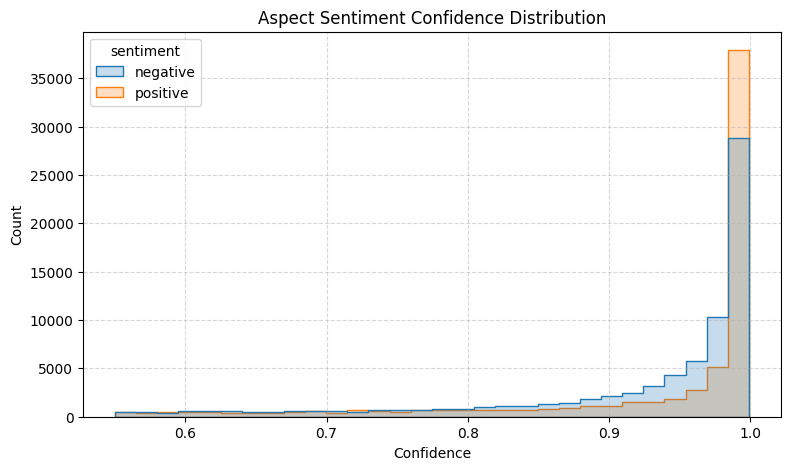

,count,mean,median,min,max
sentiment,,,,,
negative,74805,0.9229,0.9721,0.5501,0.9988
positive,65566,0.9343,0.9918,0.5503,0.9992


In [47]:
if not aspect_results.empty:
    plt.figure(figsize=(9, 5))
    sns.histplot(
        data=aspect_results, 
        x="confidence", 
        hue="sentiment", 
        bins=30, 
        element="step", 
        stat="count", 
        common_norm=False
    )
    plt.title("Aspect Sentiment Confidence Distribution")
    plt.xlabel("Confidence")
    plt.ylabel("Count")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    confidence_summary = (
        aspect_results.groupby("sentiment")["confidence"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(4)
    )
    display(confidence_summary)

## 18. Interactive Product Review Intelligence Dashboard

This dashboard combines:

- total aspect mentions
- positive/negative aspect counts
- average confidence
- sentiment distribution
- top positive aspects
- top negative aspects

It can be exported as HTML and attached to the Kaggle output.

Total Aspect Mentions: 140,371
Positive Mentions:     65,566 (46.7%)
Negative Mentions:     74,805 (53.3%)
Average Confidence:    92.82%



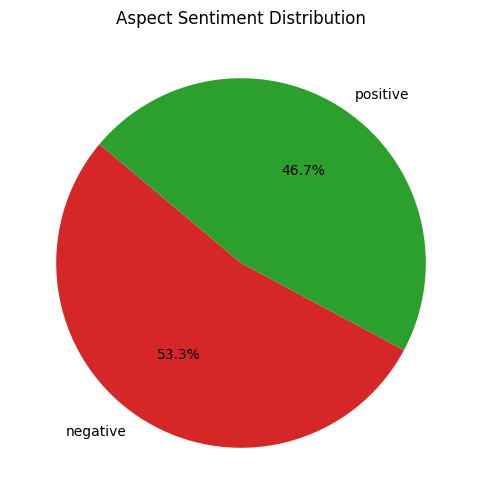

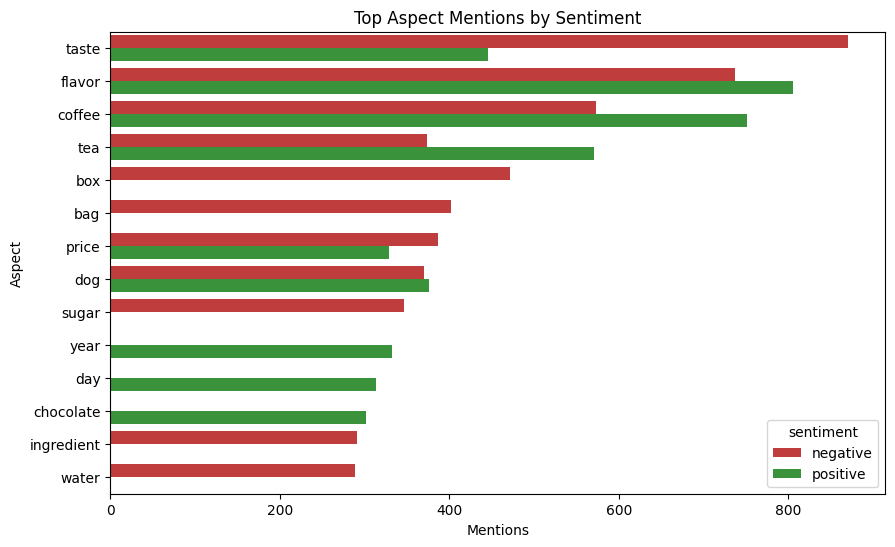

In [50]:
if not aspect_results.empty:
    # 1. Compute aggregate statistics
    total_mentions = len(aspect_results)
    positive_count = int((aspect_results["sentiment"] == "positive").sum())
    negative_count = int((aspect_results["sentiment"] == "negative").sum())
    avg_conf = aspect_results["confidence"].mean()

    print(f"Total Aspect Mentions: {total_mentions:,}")
    print(f"Positive Mentions:     {positive_count:,} ({positive_count / total_mentions:.1%})")
    print(f"Negative Mentions:     {negative_count:,} ({negative_count / total_mentions:.1%})")
    print(f"Average Confidence:    {avg_conf:.2%}\n")

    # 2. Aspect Sentiment Pie Chart
    sentiment_counts = aspect_results["sentiment"].value_counts()
    plt.figure(figsize=(6, 6))
    plt.pie(
        sentiment_counts, 
        labels=sentiment_counts.index, 
        autopct='%1.1f%%', 
        colors=["#2ca02c" if label == "positive" else "#d62728" for label in sentiment_counts.index],
        startangle=140
    )
    plt.title("Aspect Sentiment Distribution")
    plt.show()

    # 3. Top Aspect Mentions by Sentiment
    top = (
        aspect_results.groupby(["aspect", "sentiment"])
        .size()
        .reset_index(name="mentions")
        .sort_values("mentions", ascending=False)
        .head(20)
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top,
        x="mentions",
        y="aspect",
        hue="sentiment",
        palette={"positive": "#2ca02c", "negative": "#d62728"}
    )
    plt.title("Top Aspect Mentions by Sentiment")
    plt.xlabel("Mentions")
    plt.ylabel("Aspect")
    plt.show()

## 19. Real-time review analyzer

Use this function to enter any new customer review. It returns candidate aspects, predicted sentiment, confidence, and the sentence used for the prediction.

In [51]:
def analyze_review(review, min_confidence=0.55):
    result = aspect_sentiment(review, min_confidence=min_confidence)

    if result.empty:
        overall_sentiment, overall_confidence = predict_sentiment(review)

        return {
            "overall_sentiment": overall_sentiment,
            "overall_confidence": round(overall_confidence, 4),
            "aspects": []
        }

    return {
        "overall_sentiment": predict_sentiment(review)[0],
        "overall_confidence": round(predict_sentiment(review)[1], 4),
        "aspects": result.to_dict("records")
    }

new_review = (
    "I really like the taste and quality of this product. "
    "The packaging is poor, though, and the price is too high."
)

analysis = analyze_review(new_review)
analysis

{'overall_sentiment': 'positive',
 'overall_confidence': 0.9895,
 'aspects': [{'aspect': 'quality',
   'sentiment': 'positive',
   'confidence': 0.9987,
   'sentence': 'I really like the taste and quality of this product.'},
  {'aspect': 'taste',
   'sentiment': 'positive',
   'confidence': 0.9987,
   'sentence': 'I really like the taste and quality of this product.'},
  {'aspect': 'the taste',
   'sentiment': 'positive',
   'confidence': 0.9987,
   'sentence': 'I really like the taste and quality of this product.'},
  {'aspect': 'packaging',
   'sentiment': 'negative',
   'confidence': 0.9595,
   'sentence': 'The packaging is poor, though, and the price is too high.'},
  {'aspect': 'price',
   'sentiment': 'negative',
   'confidence': 0.9595,
   'sentence': 'The packaging is poor, though, and the price is too high.'},
  {'aspect': 'the packaging',
   'sentiment': 'negative',
   'confidence': 0.9595,
   'sentence': 'The packaging is poor, though, and the price is too high.'},
  {'aspec

## 20. Save model and aspect results

These files can be downloaded from Kaggle's `/kaggle/working` output.

In [52]:
OUTPUT_DIR = "/kaggle/working/product_review_intelligence"

os.makedirs(OUTPUT_DIR, exist_ok=True)

trainer.save_model(OUTPUT_DIR + "/sentiment_model")
tokenizer.save_pretrained(OUTPUT_DIR + "/sentiment_model")

if not aspect_results.empty:
    aspect_results.to_csv(
        OUTPUT_DIR + "/aspect_sentiment_results.csv",
        index=False
    )

top_aspects.to_csv(
    OUTPUT_DIR + "/candidate_aspects.csv",
    index=False
)

print("Saved to:", OUTPUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /kaggle/working/product_review_intelligence


## 21. Export dashboard data as HTML

Plotly figures can be exported as standalone HTML files.

In [54]:
if not aspect_results.empty:
    dashboard_html = OUTPUT_DIR + "/aspect_sentiment_dashboard.html"
    
    top_df = top.sort_values("mentions")
    
    fig = go.Figure()
    
    for sentiment, color in [("negative", "#d62728"), ("positive", "#2ca02c")]:
        sub_df = top_df[top_df["sentiment"] == sentiment]
        if not sub_df.empty:
            fig.add_trace(go.Bar(
                y=sub_df["aspect"],
                x=sub_df["mentions"],
                name=sentiment,
                orientation="h",
                marker_color=color
            ))

    fig.update_layout(
        title="Product Review Intelligence — Aspect Sentiment",
        barmode="stack",
        xaxis_title="Mentions",
        yaxis_title="Aspect"
    )
    
    fig.write_html(dashboard_html)
    print("Dashboard saved to:", dashboard_html)

Dashboard saved to: /kaggle/working/product_review_intelligence/aspect_sentiment_dashboard.html


# Project architecture

```text
Amazon Fine Food Reviews
          |
          v
   Data Cleaning / EDA
          |
          v
  Rating -> Sentiment Label
      1-2       4-5
          |
          v
   DistilBERT Fine-tuning
          |
          v
    Sentiment Predictor
          |
          +-------------------+
          |                   |
          v                   v
 Candidate Aspect       Sentence Split
 Extraction                  |
          |                   |
          +---------> Aspect Matching
                              |
                              v
                    Aspect Sentiment Model
                              |
                              v
                Sentiment + Confidence
                              |
                              v
                 Aggregation / Analytics
                              |
                              v
                    Plotly Dashboard
```

## Limitations and future improvements

1. The sentiment labels are derived from star ratings, not manually annotated aspect sentiment.
2. Candidate aspect extraction is rule/dependency based and may extract irrelevant nouns.
3. Sentence-level sentiment inherits the weakness of review-level supervision.
4. A stronger research version should fine-tune an ABSA model on an aspect-annotated dataset such as SemEval-2014 Task 4.
5. For production, store extracted aspect records in PostgreSQL/Elasticsearch and expose the model through a FastAPI service.
6. Add aspect normalization/clustering so terms such as `price`, `cost`, and `expensive` map to a common business aspect.
